<a href="https://colab.research.google.com/github/Arobnett/HDX-sources-and-more-API-connection/blob/main/notebooks/00_main_run_all_open_source.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Arobnett/HDX-sources-and-more-API-connection/blob/main/notebooks/00_main_run_all_open_source.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 00 Main Run All Open Source

Runs the validated public-source pipeline and downloads a timestamped package containing Bronze, Silver, Gold, validation, EDA reports, and EDA visuals.

**Public-data boundary:** this notebook does not use restricted target variables or internal operational datasets.


In [1]:
from pathlib import Path  # Work with repository paths.

REPO_URL = "https://github.com/Arobnett/HDX-sources-and-more-API-connection.git"  # Public pipeline repository.
REPO_DIR = Path("/content/HDX-sources-and-more-API-connection")  # Colab checkout location.

%cd /content

if not REPO_DIR.exists():  # Clone the repository in a fresh runtime.
    !git clone {REPO_URL} {REPO_DIR}

%cd /content/HDX-sources-and-more-API-connection

!git checkout main  # Use the validated default branch.
!git pull origin main  # Refresh the local checkout.
!git lfs install  # Enable large-file support.
!git lfs pull  # Retrieve Git LFS-managed public inputs.
!pip install -q pycountry  # Install the ISO country reference used by geographic validation.


/content
/content/HDX-sources-and-more-API-connection
Already on 'main'
Your branch is up to date with 'origin/main'.
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 8 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 4.22 KiB | 1.41 MiB/s, done.
From https://github.com/Arobnett/HDX-sources-and-more-API-connection
 * branch            main       -> FETCH_HEAD
   dd35c6d..baa8f8c  main       -> origin/main
Updating dd35c6d..baa8f8c
Fast-forward
 notebooks/00_main_run_all_open_source.ipynb | 2249 ++-------------------------
 1 file changed, 167 insertions(+), 2082 deletions(-)
Updated Git hooks.
Git LFS initialized.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 33.3 MB/s eta 0:00:00


In [2]:
import importlib.util  # Load repository modules directly from source files.
import sys  # Register loaded modules for cross-module imports.
from pathlib import Path  # Work with filesystem paths.

PROJECT_ROOT = Path("/content/HDX-sources-and-more-API-connection")  # Set repository root.
SRC_DIR = PROJECT_ROOT / "src"  # Set reusable source-code directory.

def load_module(module_name, module_path):  # Load one repository Python module.
    spec = importlib.util.spec_from_file_location(module_name, module_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

paths = load_module("paths", SRC_DIR / "paths.py")  # Load canonical paths first.
cleaning = load_module("cleaning", SRC_DIR / "cleaning.py")  # Load Silver cleaning.
geographic_keys = load_module("geographic_keys", SRC_DIR / "geographic_keys.py")  # Load geographic QA.
feature_assembly = load_module("feature_assembly", SRC_DIR / "feature_assembly.py")  # Load Gold assembly.
eda_reporting = load_module("eda_reporting", SRC_DIR / "eda_reporting.py")  # Load expanded EDA reporting.

CLEAN_DIR = paths.CLEAN_DIR
CLEAN_REPORTS_DIR = paths.CLEAN_REPORTS_DIR
FEATURE_REPORTS_DIR = paths.FEATURE_REPORTS_DIR
MODEL_FEATURES_DIR = paths.MODEL_FEATURES_DIR
EDA_REPORTS_DIR = paths.EDA_REPORTS_DIR
EDA_VISUALS_DIR = paths.OUTPUTS_DIR / "eda_visuals"

print(f"Project root: {PROJECT_ROOT}")
print(f"Standardized source directory: {paths.SILVER_DIR}")


Project root: /content/HDX-sources-and-more-API-connection
Standardized source directory: /content/HDX-sources-and-more-API-connection/country_month_year_outputs/silver_country_month_year


In [3]:
# STEP 1 - Clean standardized public-source files into model-ready Silver tables.
silver_summary, silver_rejects = cleaning.clean_silver_directory()
display(silver_summary)

silver_errors = silver_summary[silver_summary["status"].eq("error")]
if not silver_errors.empty:
    raise RuntimeError("Silver cleaning contains failed sources.")

print(f"Clean Silver files: {len(list(CLEAN_DIR.glob('*.csv')))}")


,source_file,output_name,status,input_rows,output_rows,rejected_rows,output_bytes,key_unique,duplicate_key_rows,missing_key_columns
0,civilian_targeting_events_and_fatalities__coun...,clean_civilian_targeting_country_month.csv,ok,1036352.0,6060.0,30336.0,163806.0,True,0.0,
1,demonstration_events__country_month_year.csv,clean_demonstration_events_country_month.csv,ok,1036352.0,6060.0,30336.0,145689.0,True,0.0,
2,political_violence_events_and_fatalities__coun...,clean_political_violence_country_month.csv,ok,1036352.0,6060.0,30336.0,168206.0,True,0.0,
3,who_covid_19_global_daily_data__country_month_...,clean_who_covid_country_month.csv,ok,573360.0,18407.0,16723.0,808941.0,True,0.0,
4,gdacs_rss_information__country_month_year.csv,clean_gdacs_country_month.csv,ok,477.0,51.0,8.0,2267.0,True,0.0,
5,views_conflict_forecasts_country_month__countr...,clean_views_conflict_forecasts_country_month.csv,ok,1000.0,1000.0,0.0,46568.0,True,0.0,
6,inform_risk_index_trends__country_month_year.csv,clean_inform_risk_country_month.csv,ok,7640.0,22920.0,0.0,992941.0,True,0.0,
7,whs2026_datadownload_as_of_2026_08_02__country...,clean_whs2026_country_month.csv,ok,8299.0,16008.0,93.0,128865948.0,True,0.0,
8,worldriskindex_trend__country_month_year.csv,clean_worldriskindex_country_month.csv,ok,5018.0,60216.0,0.0,88025500.0,True,0.0,
9,hdx_colab_download_manifest__country_month_yea...,metadata_only_hdx_download_manifest.csv,metadata_skipped,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Clean Silver files: 9


In [4]:
# STEP 2 - Enforce canonical geographic keys before cross-source joins.
geo_summary = geographic_keys.validate_clean_directory(CLEAN_DIR, CLEAN_REPORTS_DIR)
display(geo_summary)

if geo_summary.empty:
    raise RuntimeError("Geographic validation returned no Silver sources.")

if not geo_summary["key_unique"].all():
    raise RuntimeError("At least one Silver source failed geographic-key uniqueness.")

print("Silver geographic validation passed.")


,source_file,input_rows,accepted_rows,rejected_rows,key_unique
0,clean_civilian_targeting_country_month.csv,6060,5356,704,True
1,clean_demonstration_events_country_month.csv,6060,5356,704,True
2,clean_gdacs_country_month.csv,51,38,13,True
3,clean_inform_risk_country_month.csv,22920,21360,1560,True
4,clean_political_violence_country_month.csv,6060,5356,704,True
5,clean_views_conflict_forecasts_country_month.csv,1000,853,147,True
6,clean_who_covid_country_month.csv,18407,16669,1738,True
7,clean_whs2026_country_month.csv,16008,14616,1392,True
8,clean_worldriskindex_country_month.csv,60216,54912,5304,True


Silver geographic validation passed.


In [5]:
# STEP 3 - Assemble the validated public Gold feature table.
gold_features, assembly_report, feature_catalog = feature_assembly.assemble_feature_table()

display(assembly_report)

KEY_COLUMNS = ["iso3", "country", "year", "month"]
duplicate_gold_keys = int(gold_features.duplicated(KEY_COLUMNS).sum())

if gold_features.empty:
    raise RuntimeError("Gold feature table is empty.")

if duplicate_gold_keys:
    raise RuntimeError(f"Gold contains {duplicate_gold_keys} duplicate modeling keys.")

print(f"Gold rows: {len(gold_features):,}")
print(f"Gold columns: {len(gold_features.columns):,}")
print(f"Duplicate Gold keys: {duplicate_gold_keys:,}")


Base sources merged: 7
Zero-coverage sources excluded: []
Wide sources deferred: ['clean_whs2026_country_month.csv', 'clean_worldriskindex_country_month.csv']
Base feature rows: 28,936
Base feature columns: 23
Wrote: /content/HDX-sources-and-more-API-connection/outputs/model_features/base_feature_table_country_month_year.csv


,source_file,input_rows,feature_columns,key_unique,duplicate_key_rows,missing_key_columns,assembly_role,included_in_base_table,assembled_output_name,assembled_rows,assembled_columns,assembled_key_unique,assembled_duplicate_key_rows,assembled_missing_key_columns
0,clean_civilian_targeting_country_month.csv,5356.0,2,True,0.0,,base_feature_table,True,base_feature_table_country_month_year.csv,28936,23,True,0,
1,clean_demonstration_events_country_month.csv,5356.0,1,True,0.0,,base_feature_table,True,base_feature_table_country_month_year.csv,28936,23,True,0,
2,clean_gdacs_country_month.csv,38.0,3,True,0.0,,base_feature_table,True,base_feature_table_country_month_year.csv,28936,23,True,0,
3,clean_inform_risk_country_month.csv,21360.0,4,True,0.0,,base_feature_table,True,base_feature_table_country_month_year.csv,28936,23,True,0,
4,clean_political_violence_country_month.csv,5356.0,2,True,0.0,,base_feature_table,True,base_feature_table_country_month_year.csv,28936,23,True,0,
5,clean_views_conflict_forecasts_country_month.csv,853.0,3,True,0.0,,base_feature_table,True,base_feature_table_country_month_year.csv,28936,23,True,0,
6,clean_who_covid_country_month.csv,16669.0,4,True,0.0,,base_feature_table,True,base_feature_table_country_month_year.csv,28936,23,True,0,
7,clean_whs2026_country_month.csv,NaN,7972,None,NaN,,wide_feature_block_later,False,base_feature_table_country_month_year.csv,28936,23,True,0,
8,clean_worldriskindex_country_month.csv,NaN,245,None,NaN,,wide_feature_block_later,False,base_feature_table_country_month_year.csv,28936,23,True,0,


Gold rows: 28,936
Gold columns: 23
Duplicate Gold keys: 0


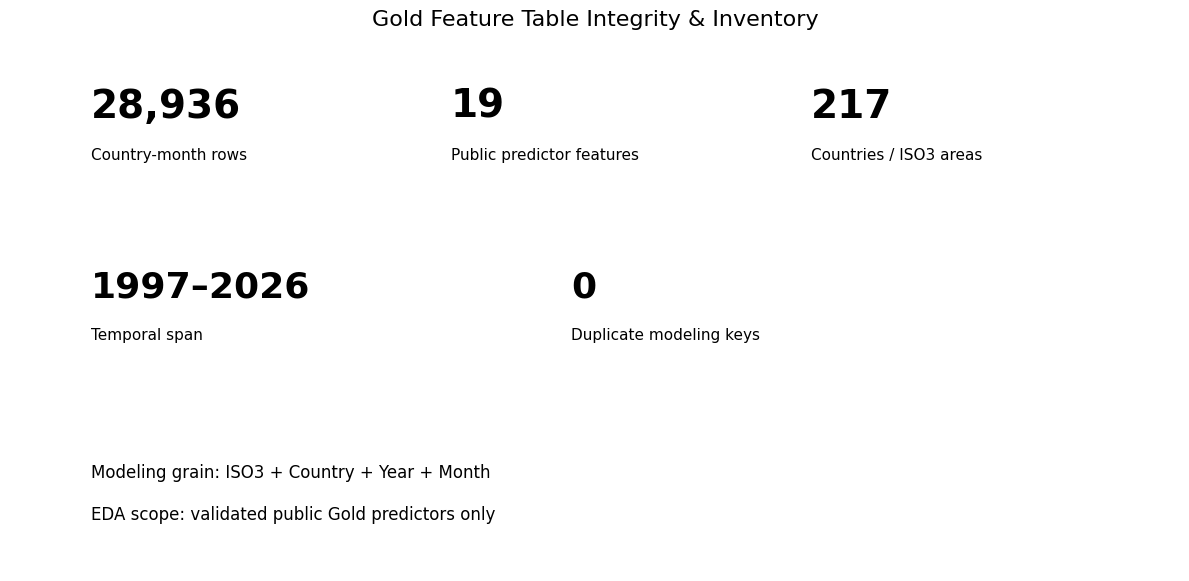

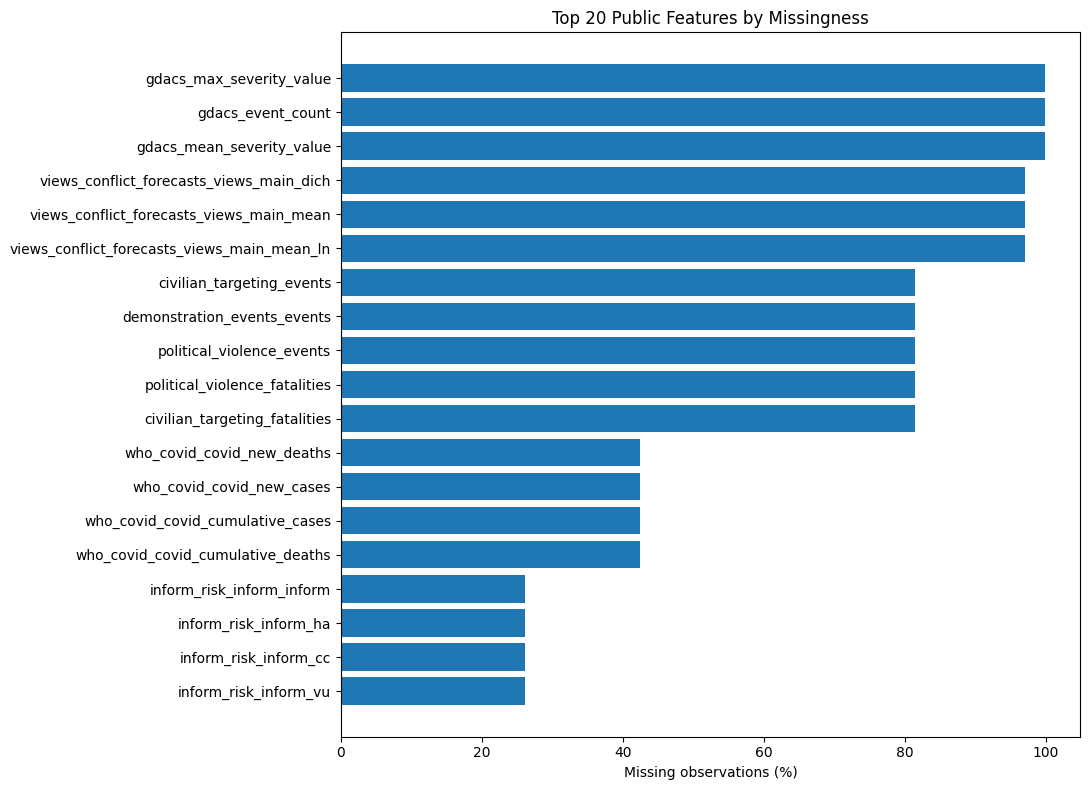

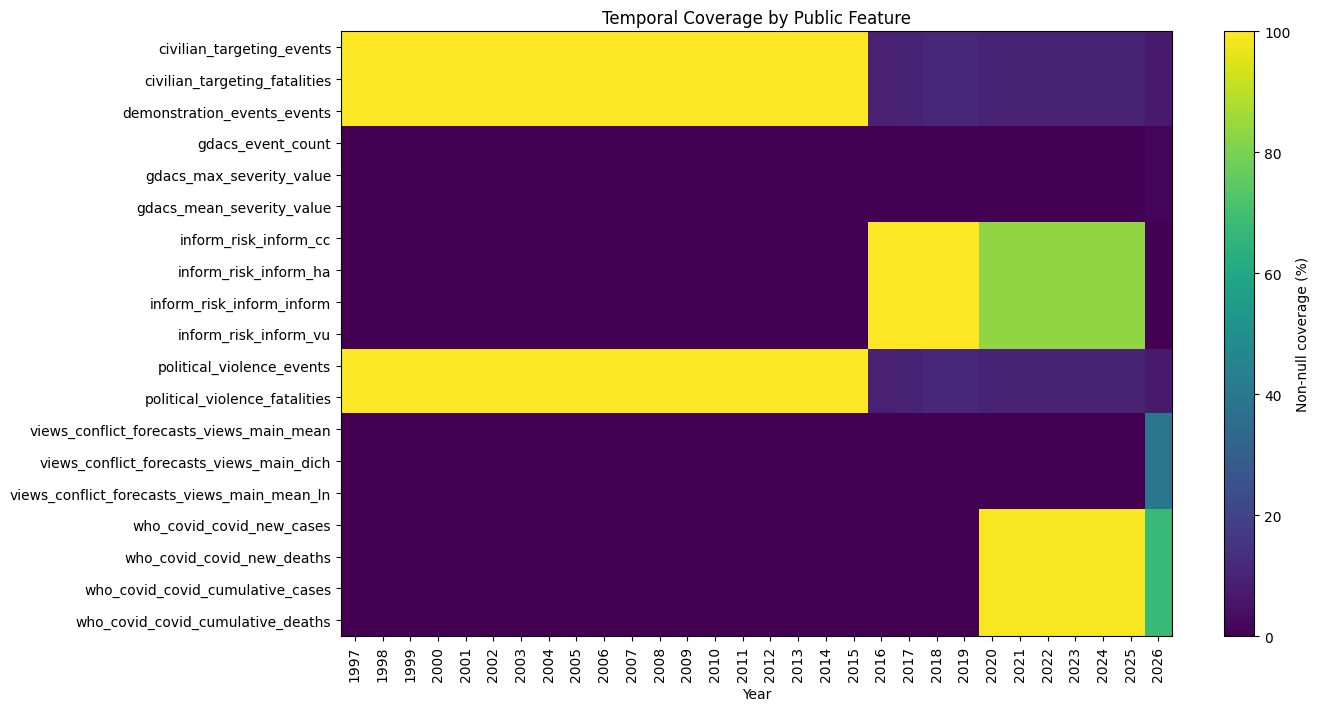

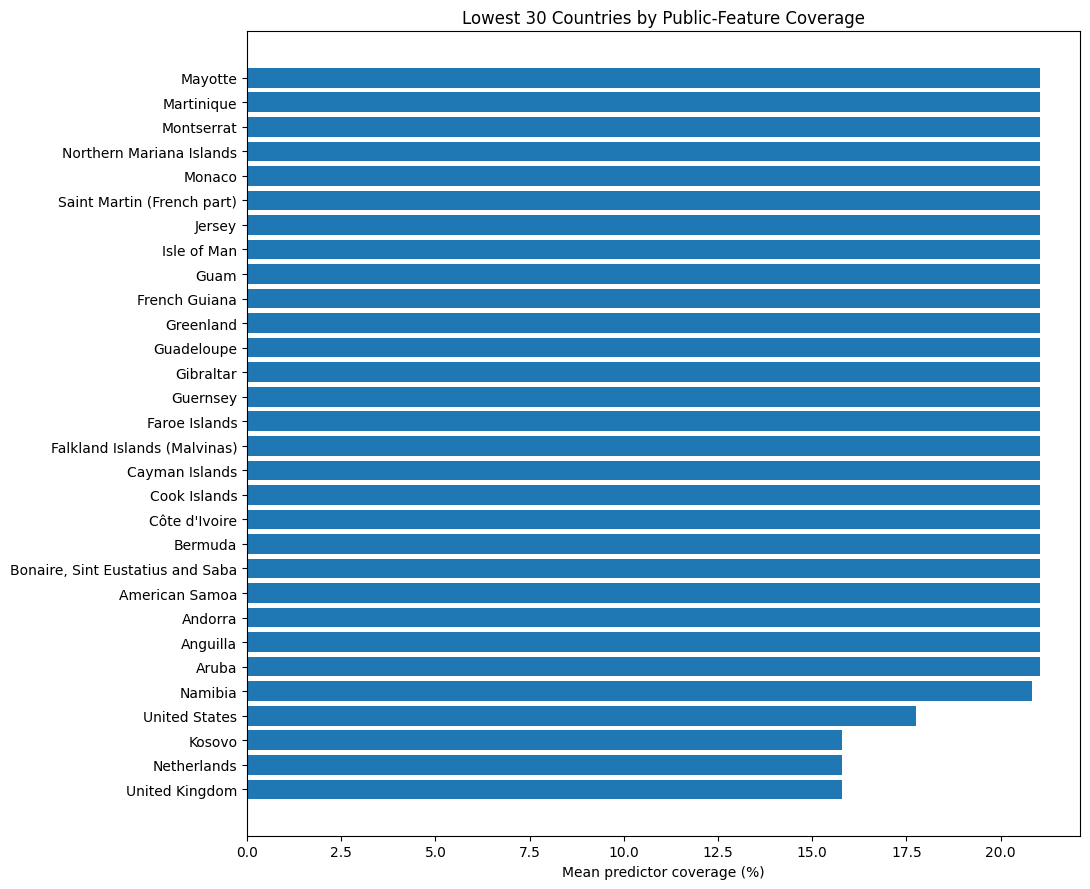

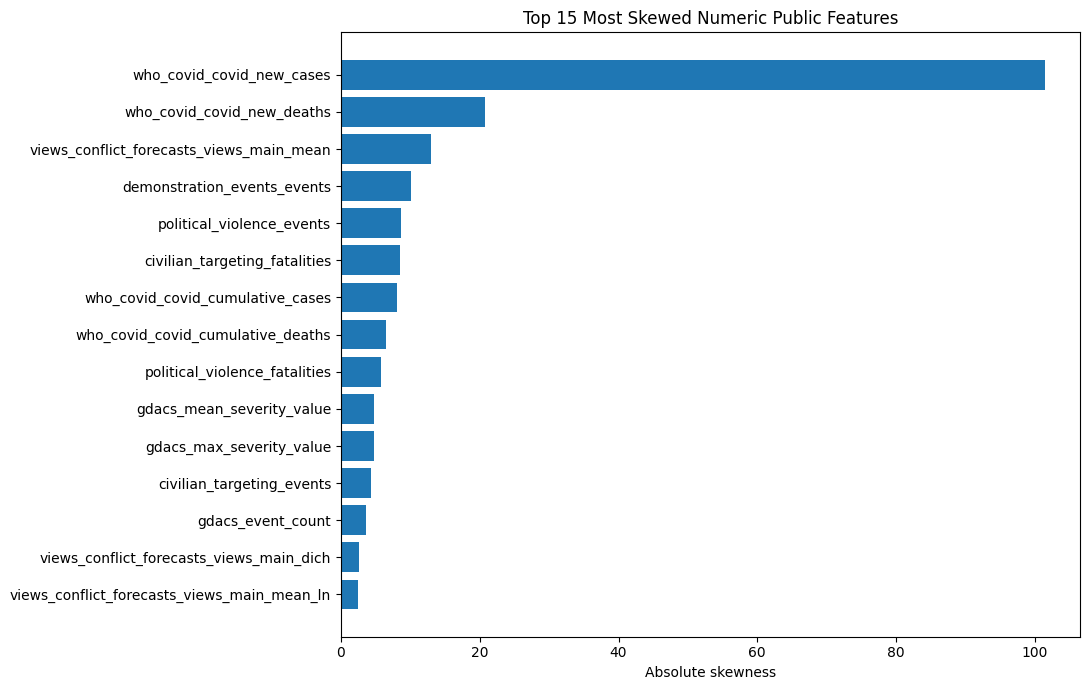

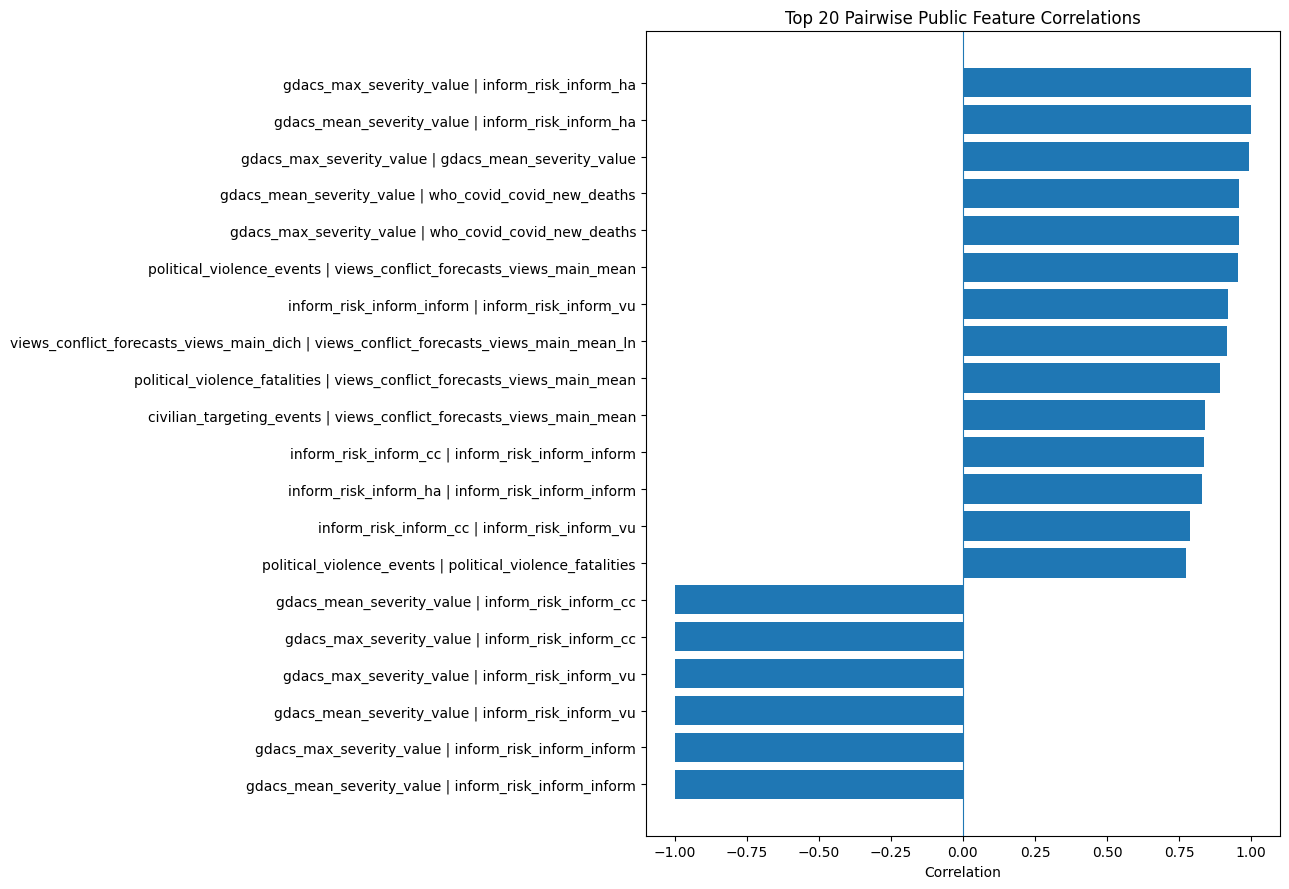

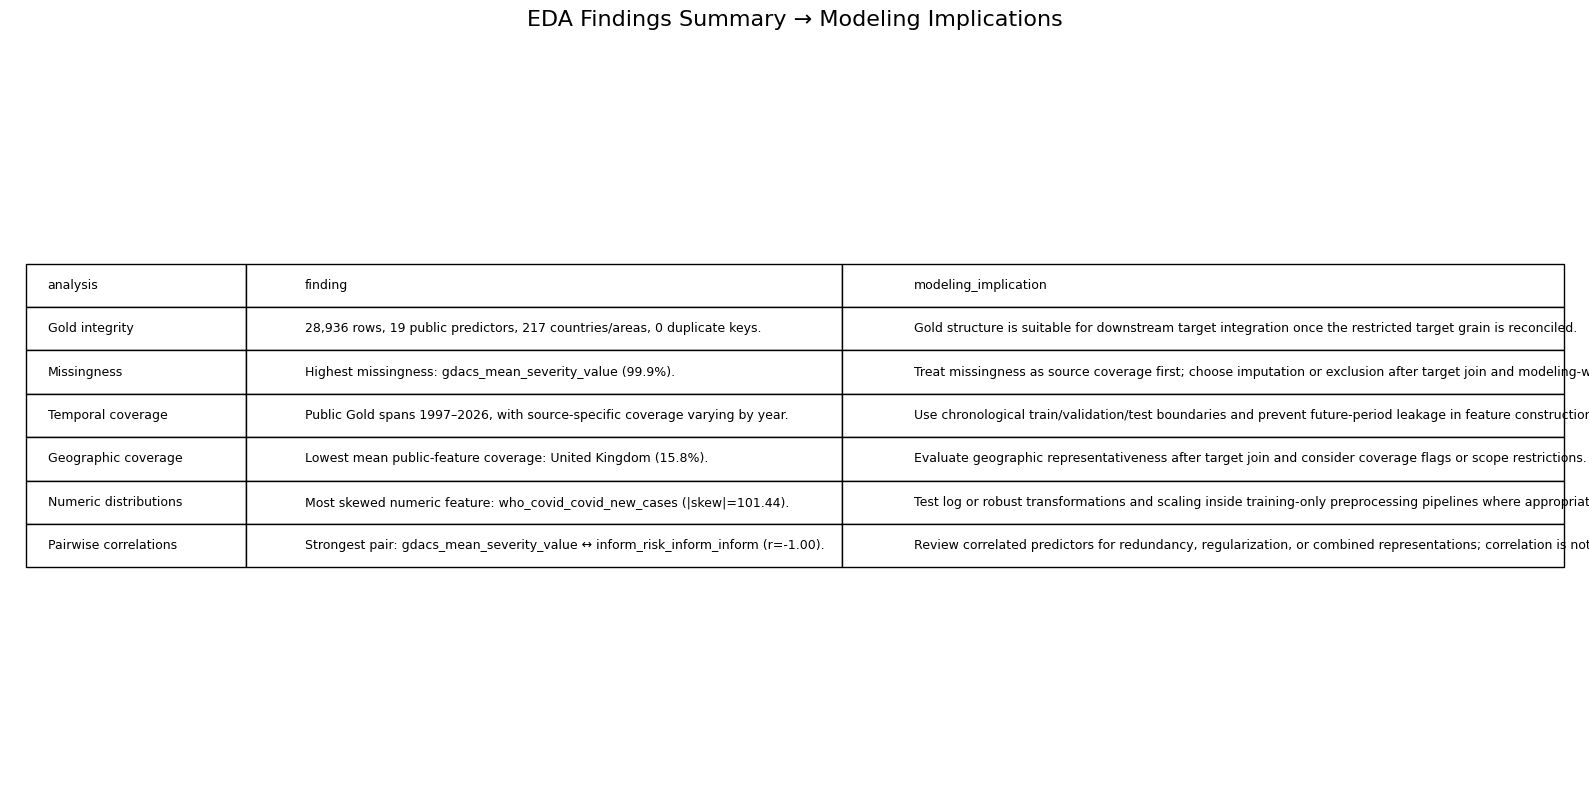


EDA report files:
 - base_feature_country_coverage.csv
 - base_feature_gold_integrity.csv
 - base_feature_meaningful_correlations.csv
 - base_feature_missingness.csv
 - base_feature_numeric_summary.csv
 - base_feature_year_coverage.csv
 - eda_findings_summary.csv

EDA visual files:
 - base_feature_meaningful_correlations.png
 - base_feature_top_missingness.png
 - base_feature_year_coverage.png
 - eda_findings_summary.png
 - feature_missingness.png
 - geographic_coverage.png
 - gold_integrity_summary.png
 - numeric_distributions.png
 - pairwise_feature_correlations.png
 - temporal_coverage.png
Expanded EDA validation passed: 7 expected visuals created.


In [6]:
# STEP 4 - Generate all public-feature EDA reports and reusable PNG visuals.
eda_outputs = eda_reporting.generate_eda_outputs(
    gold_features,
    EDA_REPORTS_DIR,
    EDA_VISUALS_DIR,
)

print("\nEDA report files:")
for path in sorted(EDA_REPORTS_DIR.glob("*")):
    print(f" - {path.name}")

print("\nEDA visual files:")
for path in sorted(EDA_VISUALS_DIR.glob("*.png")):
    print(f" - {path.name}")

expected_visuals = {
    "gold_integrity_summary.png",
    "feature_missingness.png",
    "temporal_coverage.png",
    "geographic_coverage.png",
    "numeric_distributions.png",
    "pairwise_feature_correlations.png",
    "eda_findings_summary.png",
}

missing_visuals = expected_visuals - {path.name for path in EDA_VISUALS_DIR.glob("*.png")}
if missing_visuals:
    raise RuntimeError(f"Missing expected EDA visuals: {sorted(missing_visuals)}")

print(f"Expanded EDA validation passed: {len(expected_visuals)} expected visuals created.")


In [7]:
# STEP 5 - Package the public pipeline outputs into short, SharePoint/Windows-friendly folders.
import shutil  # Copy output folders and create the ZIP archive.
from datetime import datetime, timezone  # Timestamp each exported pipeline run.

EXPORT_ROOT = Path("/content/public_crisis_risk_pipeline_export")  # Build a temporary export tree.
if EXPORT_ROOT.exists():
    shutil.rmtree(EXPORT_ROOT)
EXPORT_ROOT.mkdir(parents=True)

def copy_folder(source, destination):  # Copy one generated output folder when present.
    destination.mkdir(parents=True, exist_ok=True)
    if source.exists():
        for item in source.iterdir():
            target = destination / item.name
            if item.is_dir():
                shutil.copytree(item, target, dirs_exist_ok=True)
            else:
                shutil.copy2(item, target)

copy_folder(PROJECT_ROOT / "country_month_year_outputs", EXPORT_ROOT / "01_bronze")
copy_folder(CLEAN_DIR, EXPORT_ROOT / "02_silver")
copy_folder(MODEL_FEATURES_DIR, EXPORT_ROOT / "03_gold")
copy_folder(FEATURE_REPORTS_DIR, EXPORT_ROOT / "04_validation")
copy_folder(CLEAN_REPORTS_DIR, EXPORT_ROOT / "04_validation")
copy_folder(EDA_REPORTS_DIR, EXPORT_ROOT / "05_eda")
copy_folder(EDA_VISUALS_DIR, EXPORT_ROOT / "06_visuals")

timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
zip_base = Path("/content") / f"public_crisis_risk_pipeline_{timestamp}"
zip_path = Path(shutil.make_archive(str(zip_base), "zip", EXPORT_ROOT))

print(f"Export ZIP: {zip_path}")
print(f"EDA visuals packaged: {len(list((EXPORT_ROOT / '06_visuals').glob('*.png')))}")


Export ZIP: /content/public_crisis_risk_pipeline_20260824T154557Z.zip
EDA visuals packaged: 10


In [8]:
# STEP 6 - Download the complete public pipeline package.
from google.colab import files  # Use Colab's browser download helper.

files.download(str(zip_path))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>